# FAD Demo on W_030 EEG (caregiver, Brave)

This notebook mirrors the FAD workflow from the MATLAB live-script idea, using the local NetCDF EEG data and the new Python FAD implementation in src/mtmvar.py.

Signal used: Fz channel from data/UNIWAW_imported/EEG/W_030/caregiver/W_030_EEG_cg_Brave.nc.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('..'))

from src.mtmvar import fad_decomposition, fad_components_table

In [2]:
# Load EEG dataset
nc_path = '../data/UNIWAW_imported/EEG/W_030/caregiver/W_030_EEG_cg_Brave.nc'
ds = xr.open_dataset(nc_path)
selected_channel = 'Pz'  # Change as needed
# The file has one main data variable with a descriptive name
var_name = list(ds.data_vars)[0]
sig = ds[var_name]

# Select channel
if 'channel' not in sig.dims:
    raise ValueError("Expected channel dim, got: %s" % (sig.dims,))
if selected_channel not in ds['channel'].values:
    raise ValueError('Channel %s not found in dataset' % selected_channel)

x = sig.sel(channel=selected_channel).values.astype(float)
t = ds['time'].values.astype(float)

# Estimate sampling frequency from time coordinate
dt = float(np.median(np.diff(t)))
fs = 1.0 / dt

print('Variable:', var_name)
print('Signal shape:', x.shape)
print('Estimated fs: %.6f Hz' % fs)

Variable: W_030 EEG cg Brave with ±10s margin
Signal shape: (10154,)
Estimated fs: 128.000000 Hz


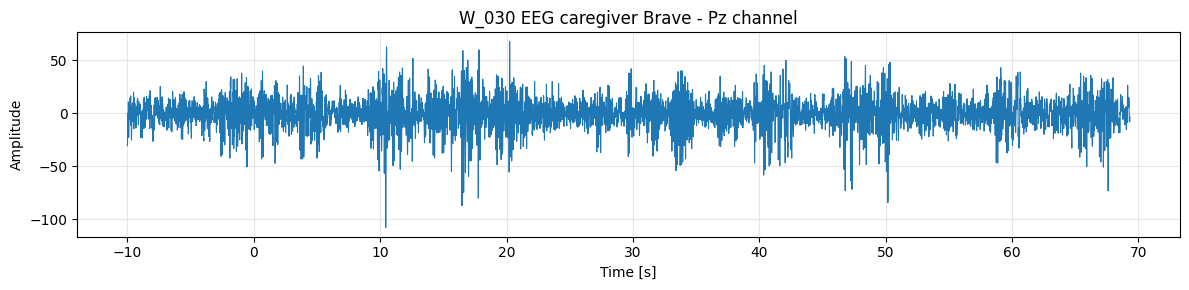

In [3]:
# Quick view of the signal
plt.figure(figsize=(12, 3))
plt.plot(t, x, lw=0.8)
plt.title(f'W_030 EEG caregiver Brave - {selected_channel} channel')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

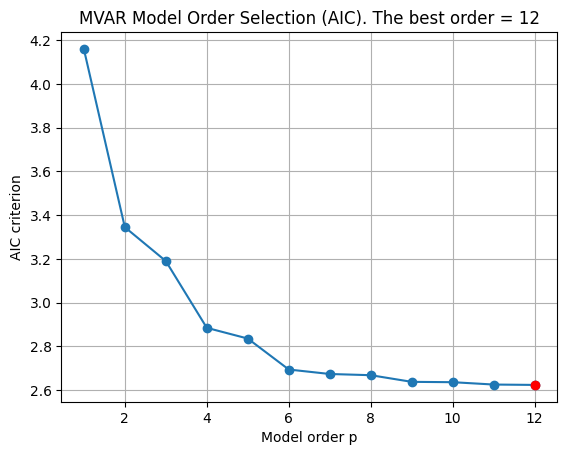

FAD: optimal AR model order (AIC) = 12


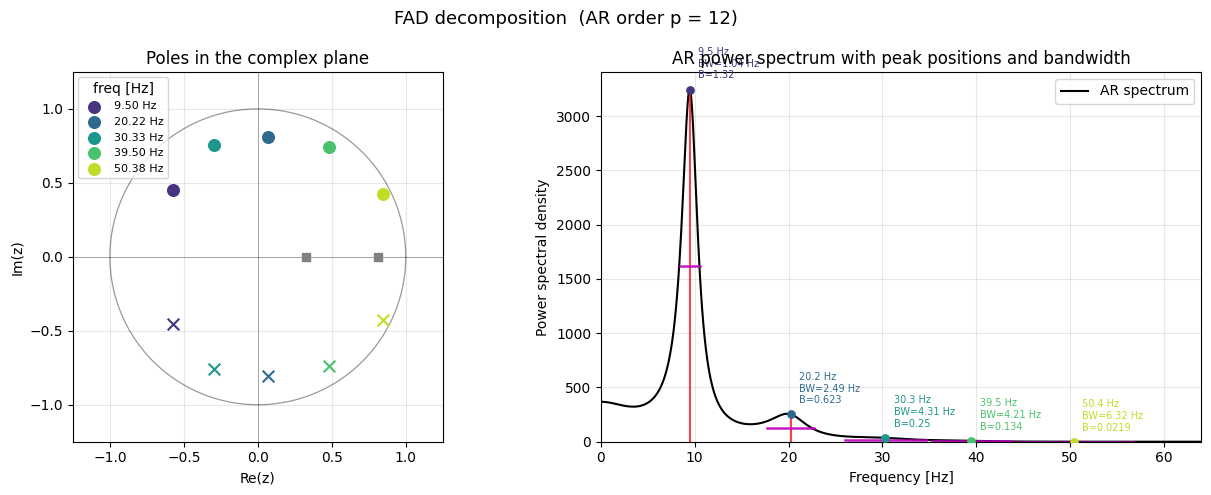

Selected AR order: 12
Number of oscillatory components (paired): 5


In [4]:
# FAD decomposition
# model_order=None => automatic order selection by AIC over max_model_order
fad = fad_decomposition(
    x,
    fs=fs,
    model_order=None,
    max_model_order=12,
    crit_type='AIC',
    plot=True,
    pair_conjugates=True
)

print('Selected AR order:', fad['model_order'])
print('Number of oscillatory components (paired):', len(fad['paired_components']['freq_hz']))

In [5]:
# Compact FAD table (DataFrame)
fad_df = fad_components_table(fad, output='dataframe', decimals=6)
fad_df

,component,freq_hz,omega_rad_s,beta_s_1,bandwidth_hz,B,phi_rad,pole_real,pole_imag,residue_real,residue_imag
0,1,9.504957,59.721407,6.542630,1.041292,1.319844,-0.785051,0.848611,0.427414,0.466797,-0.466473
1,2,20.224788,127.076090,15.660455,2.492439,0.623444,-1.641568,0.483443,0.741098,-0.022043,-0.310942
2,3,30.334586,190.597825,27.065628,4.307629,0.250497,-2.120328,0.066096,0.806706,-0.065416,-0.106808
3,4,39.503398,248.207173,26.445407,4.208917,0.133736,-2.635613,-0.292844,0.758793,-0.058490,-0.032409
4,5,50.384200,316.573265,39.739220,6.324693,0.021882,-2.727161,-0.575370,0.454309,-0.010015,-0.004406


In [6]:
# Optional export for downstream analysis
#out_csv = 'fad_w030_fz_components.csv'
#fad_df.to_csv(out_csv, index=False)
#print('Saved:', out_csv)

## Compare with FOOOFspecparam

                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
               Model was fit to the 2-40 Hz frequency range with 0.25 Hz resolution               
                                                                                                  
                               Aperiodic Parameters ('fixed' mode)                                
                                        (offset, exponent)                                        
                                          1.6014, 1.3880                                          
                                                                                                  
          

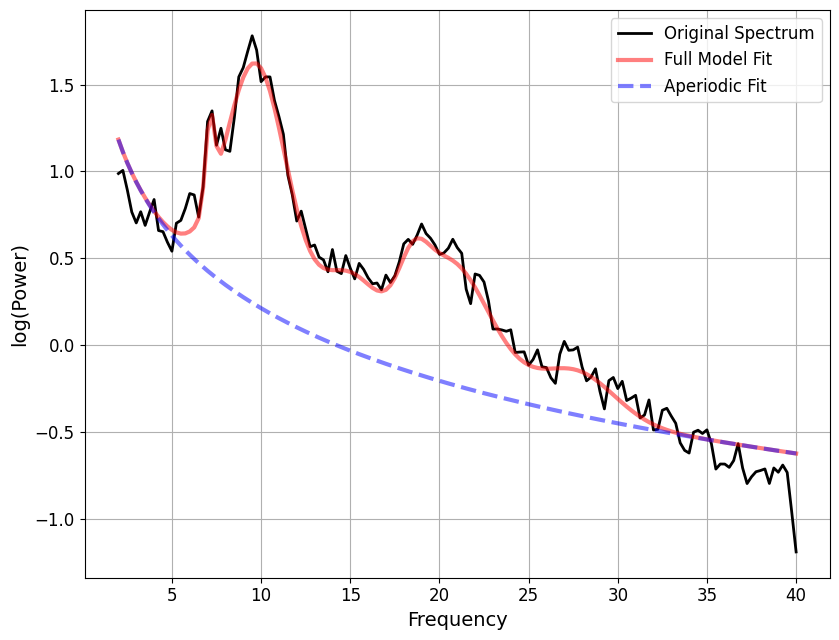

In [7]:
import scipy.signal as signal
# Import the model object
from specparam import SpectralModel
# Initialize a model object
fm = SpectralModel()

# Set the frequency range to fit the model
freq_range = [2, 40]

# Recompute and apply one shared mask to both arrays (prevents shape mismatch)
freqs_full, spectrum_full = signal.welch(x, fs=fs, nperseg=fs*4, noverlap=fs*3)
mask = (freqs_full >= freq_range[0]) & (freqs_full <= freq_range[1])
freqs = freqs_full[mask]
spectrum = spectrum_full[mask]
# Report: fit the model, print the resulting parameters, and plot the reconstruction
fm.report(freqs, spectrum, freq_range)